Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


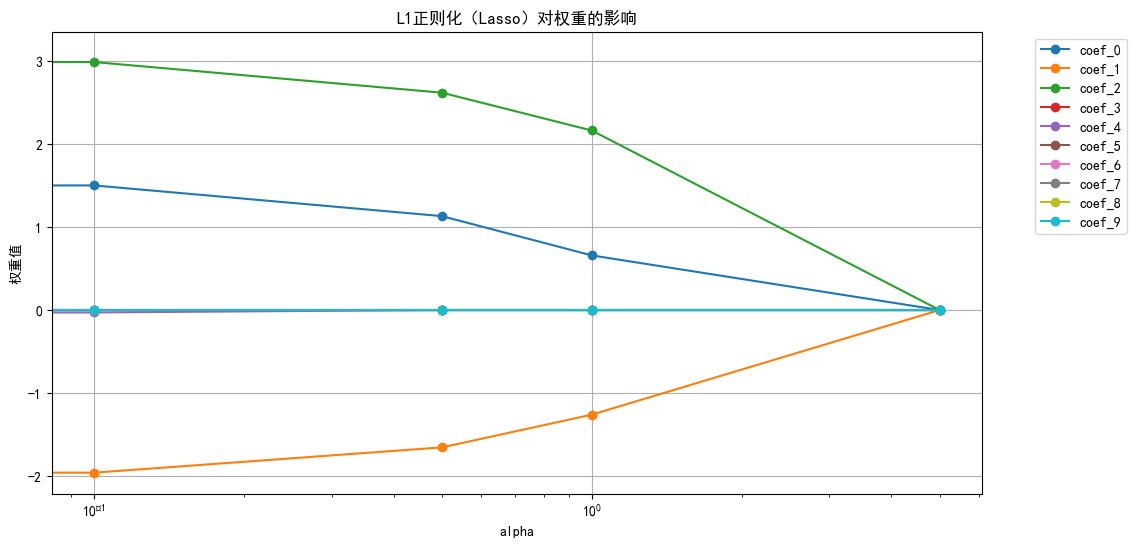

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso

# 生成数据
np.random.seed(0)
n_samples, n_features = 50, 10
X = np.random.randn(n_samples, n_features)

# 真正的权重，只有前3个非零
true_coef = np.zeros(n_features)
true_coef[:3] = [1.5, -2.0, 3.0]

# 生成目标值，带一点噪声
y = X @ true_coef + np.random.randn(n_samples) * 0.5

# 不同alpha下的Lasso
alphas = [0.0, 0.1, 0.5, 1.0, 5.0]  # alpha=0相当于普通线性回归
coefs = []

for a in alphas:
    if a == 0.0:
        model = LinearRegression()
    else:
        model = Lasso(alpha=a, max_iter=10000)
    model.fit(X, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)

# 可视化权重变化
plt.figure(figsize=(12, 6))
for i in range(n_features):
    plt.plot(alphas, coefs[:, i], marker='o', label=f'coef_{i}')
plt.xlabel('alpha')
plt.ylabel('权重值')
plt.title('L1正则化（Lasso）对权重的影响')
plt.xscale('log')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
